#### FinBERT 验证 FNSPID数据集
测试 FinBERT模型验证FNSPID_data数据集是否有效

In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os

In [ ]:
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")


Step 1: 读取测试集并抽取样本
正在读取测试集...


总样本数: 1,958,628
有效样本数: 1,958,628
抽取样本数: 1000
样本已保存到: 02_A_finbert/FNSPID_data/test_sample_1000.csv


In [ ]:

print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification



Step 2: 加载 FinBERT 模型


In [10]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: 02_A_finbert/finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!


In [11]:

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")

使用设备: cuda


In [12]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 16/16 [00:01<00:00,  8.85it/s]


In [ ]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")




Step 4: 结果分析

情感分数统计:
  均值: 0.0605
  标准差: 0.4641
  最小值: -1.0000
  最大值: 1.0000

情感标签分布:
  neutral: 759 (75.9%)
  positive: 150 (15.0%)
  negative: 91 (9.1%)

按股票代码的情感分布 (Top 10):
                  mean  count
Stock_symbol                 
AMTD         -0.189071      2
ATW          -0.499710      2
BBRY         -0.308040      2
CCJ           0.500000      2
DUK          -0.000389      2
GNW          -0.996162      2
GPOR          0.500114      2
JPM          -0.001460      2
MRVL          0.161054      2
PNR          -0.000015      2

✅ 预测结果已保存到: ./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv
   文件大小: 0.26 MB

Step 5: 高置信度样本展示（供人工验证）

样本 1:
  日期: 2013-07-22 00:00:00 UTC
  股票: N/A
  预测: negative (分数: -1.000)
  概率: 负=1.000, 中=0.000, 正=0.000
  标题: Mobistar Slumps Most Since IPO on Lower Outlook: Brussels Mover...

样本 12:
  日期: 2014-11-12 00:00:00 UTC
  股票: MWV
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Apogee Hits 52-Week High on Strong Architectural Market

情感分数分布:
count    1000.000000
mean        0.060544
std         0.464129
min        -1.000000
25%        -0.000262
50%        -0.000005
75%         0.001758
max         1.000000
Name: sentiment_score, dtype: float64


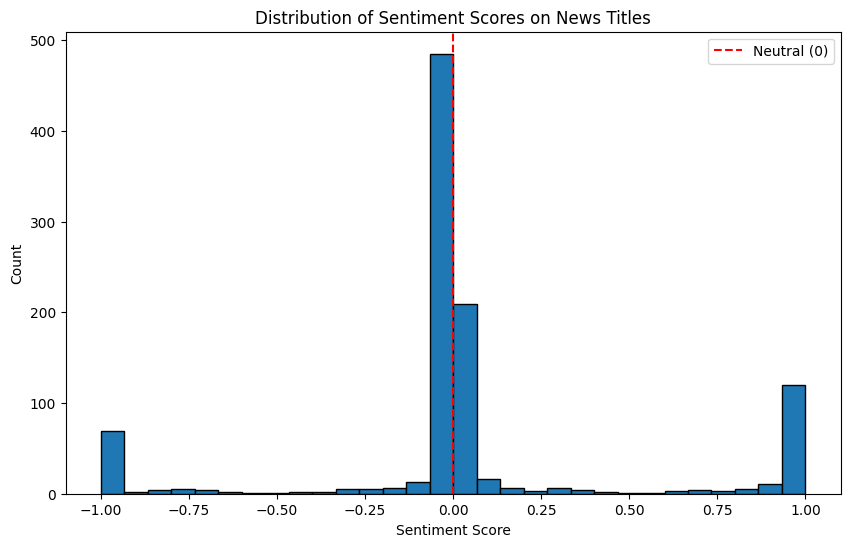


最正面样本:
  Score: 1.000 | Chegg shares are trading higher after Morgan Stanley reinsta
  Score: 1.000 |  Canacol Energy Ltd. Announces 227% Increase in Revenues and
  Score: 1.000 | Medical Marijuana Inc. in a Strong Market Position with Amen
  Score: 1.000 | SolidFire Broadens Market Reach Delivering New Scale-Out All
  Score: 1.000 | Nokia (NOK) Earnings and Revenues Surpass Estimates in Q4

最负面样本:
  Score: -1.000 | UPDATE 2-Cenovus slows Foster Creek expansion; earnings disa
  Score: -1.000 | Pentair plc. Ordinary Share Lowers FY2019 EPS Guidance from 
  Score: -1.000 | TEX-S&P;: 3 most stressed sectors hurt by slow recovery
  Score: -1.000 | Fitch: UK Non-Life London Market Insurance Continues to Face
  Score: -1.000 | Consumer confidence lowest since Katrina

模型不确定性:
  平均不确定性: 0.247
  高不确定性样本(>0.5): 242 条


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/finbert_output/FNSPID_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")

#### FinBERT 验证 BBC数据集


In [26]:
df = pd.read_csv("02_A_finbert/bbc_data/bbc_news.csv")

print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"总样本数: {len(df)}")
df.head(5)


原始数据形状: (42115, 5)
列名: ['title', 'pubDate', 'guid', 'link', 'description']
总样本数: 42115


,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [18]:

# 数据探索
print(f"\n数据集基本信息:")
print(f"总样本数: {len(df):,}")
print(f"缺失值统计:")
print(df.isnull().sum())

# 创建用于分析的文本列（结合标题和描述）
print("\n" + "="*60)
print("Step 2: 数据预处理")
print("="*60)

# 填充缺失值
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

# 创建完整文本（标题 + 描述）
# 方式1: 只使用标题（更快）
# df['text'] = df['title']

# 方式2: 结合标题和描述（更全面）
df['text'] = df['title'] + " " + df['description']

# 过滤空文本
valid_df = df[df['text'].str.strip() != ''].copy()
print(f"有效样本数: {len(valid_df):,}")
print(f"移除空文本: {len(df) - len(valid_df)} 条")

# 文本长度统计
text_lengths = valid_df['text'].str.len()
print(f"\n文本长度统计:")
print(f"  平均长度: {text_lengths.mean():.1f} 字符")
print(f"  中位数: {text_lengths.median():.0f} 字符")
print(f"  最大长度: {text_lengths.max():,} 字符")
print(f"  最小长度: {text_lengths.min():.0f} 字符")

# 随机抽取样本（可选）
sample_size = None  # 设置为None使用全部数据，或设置数字如1000

if sample_size and sample_size < len(valid_df):
    sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f"\n抽取样本数: {len(sampled_df):,}")
else:
    sampled_df = valid_df.reset_index(drop=True)
    print(f"\n使用全部样本: {len(sampled_df):,}")

# 保存处理后的样本
sample_path = "02_A_finbert/bbc_data/bbc_news_processed.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"处理后的数据已保存到: {sample_path}")



数据集基本信息:
总样本数: 42,115
缺失值统计:
title          0
pubDate        0
guid           0
link           0
description    0
dtype: int64

Step 2: 数据预处理
有效样本数: 42,115
移除空文本: 0 条

文本长度统计:
  平均长度: 164.5 字符
  中位数: 158 字符
  最大长度: 332 字符
  最小长度: 34 字符

使用全部样本: 42,115
处理后的数据已保存到: 02_A_finbert/bbc_data/bbc_news_processed.csv


In [19]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: 02_A_finbert/finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!


In [20]:

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")

使用设备: cuda


In [21]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)


# # 准备文本
# texts = sampled_df['Article_title'].fillna('').tolist()
texts = sampled_df['text'].tolist()


# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 659/659 [01:15<00:00,  8.69it/s]


In [ ]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")
print(f"  中位数: {result_df['sentiment_score'].median():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# # 按股票代码统计（如果有股票代码）
# if result_df['Stock_symbol'].notna().any():
#     print(f"\n按股票代码的情感分布 (Top 10):")
#     stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
#     stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
#     print(stock_stats.head(10))
# else:
#     print(f"\n注意: 抽取的样本中没有股票代码信息")

    
# 按时间分析（如果有pubDate）
if 'pubDate' in result_df.columns:
    print(f"\n按时间的情感趋势:")
    result_df['pubDate'] = pd.to_datetime(result_df['pubDate'], errors='coerce')
    
    # 按日期分组
    daily_sentiment = result_df.groupby(result_df['pubDate'].dt.date)['sentiment_score'].agg(['mean', 'count'])
    print(f"日期范围: {daily_sentiment.index.min()} 至 {daily_sentiment.index.max()}")
    print(f"平均每日样本数: {daily_sentiment['count'].mean():.1f}")
    
    # 显示前10天
    print(f"\n最近10天的平均情感分数:")
    print(daily_sentiment.tail(10))





# 按标题关键词分组分析（可选）
print(f"\n高情感强度新闻示例:")
# 最正面新闻
positive_top = result_df.nlargest(5, 'sentiment_score')[['title', 'sentiment_score', 'predicted_label']]
print("\n最正面新闻:")
for idx, row in positive_top.iterrows():
    print(f"  [{row['sentiment_score']:.3f}] {row['title'][:80]}...")

# 最负面新闻
negative_top = result_df.nsmallest(5, 'sentiment_score')[['title', 'sentiment_score', 'predicted_label']]
print("\n最负面新闻:")
for idx, row in negative_top.iterrows():
    print(f"  [{row['sentiment_score']:.3f}] {row['title'][:80]}...")

# 保存完整结果
output_path = "02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

# 保存统计摘要
summary = {
    'total_samples': len(result_df),
    'mean_sentiment': result_df['sentiment_score'].mean(),
    'std_sentiment': result_df['sentiment_score'].std(),
    'positive_count': (result_df['predicted_label'] == 'positive').sum(),
    'neutral_count': (result_df['predicted_label'] == 'neutral').sum(),
    'negative_count': (result_df['predicted_label'] == 'negative').sum(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("02_A_finbert/bbc_output/bbc_news_sentiment_summary.csv", index=False)
print(f"统计摘要已保存到: bbc_news_sentiment_summary.csv")

print("\n" + "="*60)
print("Step 6: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['pubDate'] if pd.notna(row.get('pubDate')) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['title'][:150]}...")
        if pd.notna(row.get('description')):
            print(f"  描述: {row['description'][:150]}...")
else:
    print("没有找到高置信度样本（置信度 > 80%）")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

if len(neutral_samples) > 0:
    for idx, row in neutral_samples.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  标题: {row['title'][:100]}...")
        print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")
else:
    print("没有找到边界样本")
                        





Step 4: 结果分析

情感分数统计:
  均值: -0.1211
  标准差: 0.4905
  最小值: -1.0000
  最大值: 1.0000
  中位数: -0.0002

情感标签分布:
  neutral: 29921 (71.0%)
  negative: 8606 (20.4%)
  positive: 3588 (8.5%)

按时间的情感趋势:
日期范围: 2013-08-30 至 2024-12-04
平均每日样本数: 41.2

最近10天的平均情感分数:
                mean  count
pubDate                    
2024-11-25 -0.073985     38
2024-11-26 -0.266086     38
2024-11-27 -0.132258     37
2024-11-28 -0.204665     30
2024-11-29 -0.148280     47
2024-11-30 -0.205452     30
2024-12-01 -0.157607     36
2024-12-02 -0.318668     39
2024-12-03 -0.323549     36
2024-12-04 -0.033673      3

高情感强度新闻示例:

最正面新闻:
  [1.000] Starmer: UK will be 'open for business' under Labour...
  [1.000] Eintracht Frankfurt v Rangers: Roofe offers boost for Scots' final hopes...
  [1.000] NHS data sale can fuel tech boom - Blair and Hague...
  [1.000] Arsenal 3-0 Bodo/Glimt: Arsenal ease to victory over Bodo/Glimt...
  [1.000] Warm weather in June boosts UK economy...

最负面新闻:
  [-1.000] The Papers: 'UK heads into reces

In [24]:
df = pd.read_csv("02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv")
df.info()
df.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            42115 non-null  object 
 1   pubDate          42115 non-null  object 
 2   guid             42115 non-null  object 
 3   link             42115 non-null  object 
 4   description      42115 non-null  object 
 5   text             42115 non-null  object 
 6   sentiment_score  42115 non-null  float64
 7   predicted_label  42115 non-null  object 
 8   negative_prob    42115 non-null  float64
 9   neutral_prob     42115 non-null  float64
 10  positive_prob    42115 non-null  float64
dtypes: float64(4), object(7)
memory usage: 3.5+ MB


,title,pubDate,guid,link,description,text,sentiment_score,predicted_label,negative_prob,neutral_prob,positive_prob
0,Ukraine: Angry Zelensky vows to punish Russian...,2022-03-07 08:01:56,https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...,Ukraine: Angry Zelensky vows to punish Russian...,-0.000677,neutral,0.000681,0.999314,0.000004
1,War in Ukraine: Taking cover in a town under a...,2022-03-06 22:49:58,https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as...",War in Ukraine: Taking cover in a town under a...,-0.946310,negative,0.946358,0.053595,0.000047
2,Ukraine war 'catastrophic for global food',2022-03-07 00:14:42,https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...,Ukraine war 'catastrophic for global food' One...,-0.999993,negative,0.999996,0.000002,0.000002


情感分数分布:
count    4.211500e+04
mean    -1.211159e-01
std      4.905398e-01
min     -1.000000e+00
25%     -1.416421e-01
50%     -1.570408e-04
75%      2.167762e-08
max      1.000000e+00
Name: sentiment_score, dtype: float64


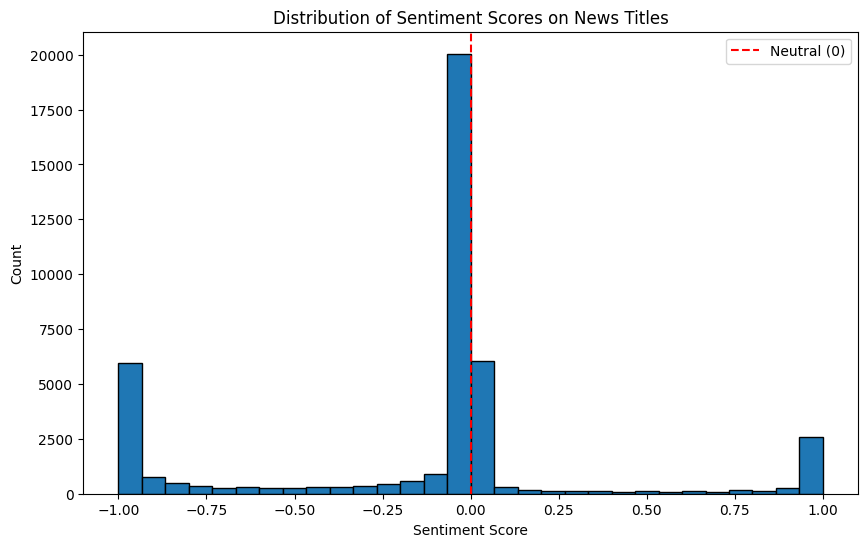


最正面样本:
  Score: 1.000 | Starmer: UK will be 'open for business' under Labour Labour 
  Score: 1.000 | Eintracht Frankfurt v Rangers: Roofe offers boost for Scots'
  Score: 1.000 | NHS data sale can fuel tech boom - Blair and Hague The forme
  Score: 1.000 | Arsenal 3-0 Bodo/Glimt: Arsenal ease to victory over Bodo/Gl
  Score: 1.000 | Warm weather in June boosts UK economy Higher temperatures h

最负面样本:
  Score: -1.000 | The Papers: 'UK heads into recession' and 'tax cut bonanza' 
  Score: -1.000 | E3: Once world's biggest gaming show permanently axed The an
  Score: -1.000 | Brexit: Progress on trade deals slower than promised The UK 
  Score: -1.000 | Parents lose hope as report says Send system broken The spec
  Score: -1.000 | Concerns over failed sports car deal 'overspend' The failed 

模型不确定性:
  平均不确定性: 0.294
  高不确定性样本(>0.5): 12221 条


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['text'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['text'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")

## FinBERT 每日每只股票的情感分数 FNSPID数据集
测试 FinBERT模型验证FNSPID_data数据集是否有效

In [4]:

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']


# ============测试1000条数据============
# print("正在读取测试集...")
# df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
# print(f"总样本数: {len(df):,}")

# # 过滤出有标题的行（所有行都有，但确保安全）
# valid_df = df[df['Article_title'].notna()].copy()
# print(f"有效样本数: {len(valid_df):,}")

# # 随机抽取1000条
# sample_size = 1000
# sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
# print(f"抽取样本数: {len(sampled_df)}")

# # 保存抽取的样本
# sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
# sampled_df.to_csv(sample_path, index=False)
# print(f"样本已保存到: {sample_path}")



# ============使用全部数据============
print("正在读取训练集...")
df = pd.read_csv("02_A_finbert/FNSPID_data/All_external.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

sampled_df = valid_df


Step 1: 读取测试集并抽取样本
正在读取训练集...


C:\Users\Xinny\AppData\Local\Temp\ipykernel_10548\377556424.py:42: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("02_A_finbert/FNSPID_data/All_external.csv", usecols=usecols)


总样本数: 13,057,514
有效样本数: 13,057,513


In [13]:
print("="*60)
print("Step 1: 读取全部数据并筛选2009年至今")
print("="*60)

# 读取全部数据（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

# ============使用全部数据 All_external.csv ============
print("正在读取全部数据...")
df = pd.read_csv("02_A_finbert/FNSPID_data/All_external.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 转换日期格式（处理带时区的格式）
print("正在转换日期格式...")
# 处理可能的时间戳格式: 1914-09-16 00:00:00+00:00
valid_df['Date'] = pd.to_datetime(valid_df['Date'], utc=True)
# 移除时区信息，统一为无时区的datetime
valid_df['Date'] = valid_df['Date'].dt.tz_localize(None)
print(f"日期范围: {valid_df['Date'].min()} 到 {valid_df['Date'].max()}")

# 筛选2009年至今
start_date = '2020-04-01'
# end_date = pd.Timestamp.now()  # 现在的日期
# end_date = '2020-06-11'  # 或者指定为 '2020-06-11'


# 方式1: 筛选到2020-06-11（数据截止日期）
end_date_data = '2020-06-11'
filtered_df = valid_df[(valid_df['Date'] >= start_date) & (valid_df['Date'] <= end_date_data)].copy()

print(f"\n筛选条件: {start_date} 到 {end_date_data}")
print(f"筛选后样本数: {len(filtered_df):,}")

# 检查实际日期范围
# print(f"实际日期范围: {filtered_df['Date'].min()} 到 {filtered_df['Date'].max()}")

# 按年份统计样本数量
print("\n按年份统计样本数量:")
filtered_df['Year'] = filtered_df['Date'].dt.year
year_counts = filtered_df['Year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"  {year}: {count:,} 条")

# 删除临时年份列
filtered_df = filtered_df.drop('Year', axis=1)

# 保存筛选后的数据
os.makedirs("02_A_finbert/FNSPID_data", exist_ok=True)
output_path = "02_A_finbert/FNSPID_data/All_external_2019_2020.csv"
filtered_df.to_csv(output_path, index=False)
print(f"\n✅ 筛选后的数据已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

sampled_df = filtered_df

Step 1: 读取全部数据并筛选2009年至今
正在读取全部数据...


C:\Users\Xinny\AppData\Local\Temp\ipykernel_10548\1400680628.py:10: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("02_A_finbert/FNSPID_data/All_external.csv", usecols=usecols)


总样本数: 13,057,514
有效样本数: 13,057,513
正在转换日期格式...
日期范围: 1914-09-16 00:00:00 到 2020-06-11 13:12:35

筛选条件: 2020-04-01 到 2020-06-11
筛选后样本数: 85,247

按年份统计样本数量:
  2020: 85,247 条

✅ 筛选后的数据已保存到: 02_A_finbert/FNSPID_data/All_external_2019_2020.csv
   文件大小: 21.61 MB


日期范围: 1914-09-16 00:00:00 到 2020-06-11 13:12:35

筛选条件: 2009-01-01 到 2020-06-11
筛选后样本数: 11,360,391

按年份统计样本数量:
  2009: 960,491 条
  2010: 1,200,802 条
  2011: 1,571,048 条
  2012: 1,569,853 条
  2013: 1,192,744 条
  2014: 1,166,278 条
  2015: 1,364,956 条
  2016: 686,338 条
  2017: 344,705 条
  2018: 523,476 条
  2019: 578,683 条
  2020: 201,017 条

✅ 筛选后的数据已保存到: 02_A_finbert/FNSPID_data/All_external_2009_2020.csv
   文件大小: 1987.25 MB

In [10]:
# 确保日期格式正确
sampled_df['Date'] = pd.to_datetime(sampled_df['Date'])
print(f"日期范围: {sampled_df['Date'].min()} 到 {sampled_df['Date'].max()}")

日期范围: 2019-01-01 00:00:00 到 2020-06-10 20:16:21


In [14]:


print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")





Step 2: 加载 FinBERT 模型
从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: 02_A_finbert/finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!
使用设备: cuda


In [15]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)

# 在预测完成后，添加按日期和股票代码的聚合
# 将 result_df 按 Date 和 Stock_symbol 分组，计算每日每只股的情感分数
daily_stock_sentiment = result_df.groupby(['Date', 'Stock_symbol']).agg({
    'sentiment_score': ['mean', 'std', 'count'],  # 平均分、标准差、新闻条数
    'predicted_label': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'neutral'  # 众数标签
}).reset_index()

# 重命名列
daily_stock_sentiment.columns = ['Date', 'Stock_symbol', 'avg_sentiment_score', 
                                  'std_sentiment_score', 'news_count', 'dominant_label']





Step 3: 批量预测情感


预测进度: 100%|██████████| 1332/1332 [01:45<00:00, 12.65it/s]


In [16]:


print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)



# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")


# 保存完整结果
output_path = "./02_A_finbert/finbert_output/time_2019-2020_FNSPID_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")


# 按日期和股票代码展示情感分数
print("\n每日每只股的情感分数 (前20条):")
print(daily_stock_sentiment.head(20))

# 按日期统计
daily_stats = result_df.groupby('Date')['sentiment_score'].mean().reset_index()
print(f"\n每日平均情感分数:")
print(daily_stats)

# 按股票统计
stock_daily_stats = result_df.groupby('Stock_symbol')['sentiment_score'].mean().reset_index()
print(f"\n每只股票的平均情感分数:")
print(stock_daily_stats)


# 保存聚合后的每日每只股情感分数
daily_output_path = "./02_A_finbert/finbert_output/time_2019-2020_FNSPID_daily_stock_sentiment.csv"
daily_stock_sentiment.to_csv(daily_output_path, index=False)
print(f"\n✅ 每日每只股的情感分数已保存到: {daily_output_path}")




Step 4: 结果分析

情感分数统计:
  均值: 0.1017
  标准差: 0.6172
  最小值: -1.0000
  最大值: 1.0000

情感标签分布:
  neutral: 49259 (29.5%)
  positive: 22287 (13.3%)
  negative: 13701 (8.2%)

按股票代码的情感分布 (Top 10):
                  mean  count
Stock_symbol                 
AAPL          0.071104    311
AMZN          0.211115    278
ALK           0.222842     81
AMD           0.224976     80
AAL           0.075275     69
AMGN          0.155215     51
AMTD          0.163772     51
AIG          -0.013465     49
ALXN          0.142861     48
ALGT          0.296626     48

✅ 预测结果已保存到: ./02_A_finbert/finbert_output/time_2019-2020_FNSPID_1000_predictions.csv
   文件大小: 29.85 MB

每日每只股的情感分数 (前20条):
         Date Stock_symbol  avg_sentiment_score  std_sentiment_score  \
0  2020-04-01            A            -0.999788                  NaN   
1  2020-04-01          AAL            -0.500104             0.577229   
2  2020-04-01          AAN                  NaN                  NaN   
3  2020-04-01          AAP            -0.0

In [17]:

# 按日期统计
daily_stats = result_df.groupby('Date')['sentiment_score'].mean().reset_index()
print(f"\n每日平均情感分数:")
print(daily_stats)

# 按股票统计
stock_daily_stats = result_df.groupby('Stock_symbol')['sentiment_score'].mean().reset_index()
print(f"\n每只股票的平均情感分数:")
print(stock_daily_stats)


# 保存聚合后的按日期统计
daily_stats_output_path = "./02_A_finbert/finbert_output/time_2019-2020_FNSPID_daily_stats.csv"
daily_stats.to_csv(daily_stats_output_path, index=False)
print(f"\n✅ 按日期统计已保存到: {daily_stats_output_path}")


# 保存聚合后的按股票统计
stock_daily_stats_output_path = "./02_A_finbert/finbert_output/time_2019-2020_FNSPID_stock_daily_stats.csv"
stock_daily_stats.to_csv(stock_daily_stats_output_path, index=False)
print(f"\n✅ 按股票统计已保存到: {stock_daily_stats_output_path}")


每日平均情感分数:
                     Date  sentiment_score
0     2020-04-01 00:00:00         0.106321
1     2020-04-01 00:31:40              NaN
2     2020-04-01 00:39:39              NaN
3     2020-04-01 00:50:24        -0.001458
4     2020-04-01 01:17:22              NaN
...                   ...              ...
11046 2020-06-10 13:14:01              NaN
11047 2020-06-10 13:21:16              NaN
11048 2020-06-10 13:42:07              NaN
11049 2020-06-10 13:56:39              NaN
11050 2020-06-10 20:16:21              NaN

[11051 rows x 2 columns]

每只股票的平均情感分数:
     Stock_symbol  sentiment_score
0               A         0.172561
1              AA        -0.005099
2            AADR              NaN
3             AAL         0.075275
4            AAMC        -0.000004
...           ...              ...
3750           ZN              NaN
3751         ZNGA              NaN
3752          ZTR              NaN
3753          ZTS              NaN
3754         ZUMZ              NaN

[3755 rows x

In [18]:

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")




Step 5: 高置信度样本展示（供人工验证）

样本 6:
  日期: 2020-05-22 07:23:25
  股票: A
  预测: negative (分数: -1.000)
  概率: 负=1.000, 中=0.000, 正=0.000
  标题: CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85...

样本 8:
  日期: 2020-05-22 05:07:04
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results....

样本 9:
  日期: 2020-05-22 04:37:59
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Wells Fargo Maintains Overweight on Agilent Technologies, Raises Price Target to $95...

样本 12:
  日期: 2020-05-22 00:00:00
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: SVB Leerink Maintains Outperform on Agilent Technologies, Raises Price Target to $95...

样本 14:
  日期: 2020-05-21 00:00:00
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Agilent Technologies shares are trading higher after the company re

#### 可视化

情感分数分布:
count    85247.000000
mean         0.101746
std          0.617236
min         -1.000000
25%         -0.000392
50%         -0.000003
75%          0.662164
max          1.000000
Name: sentiment_score, dtype: float64


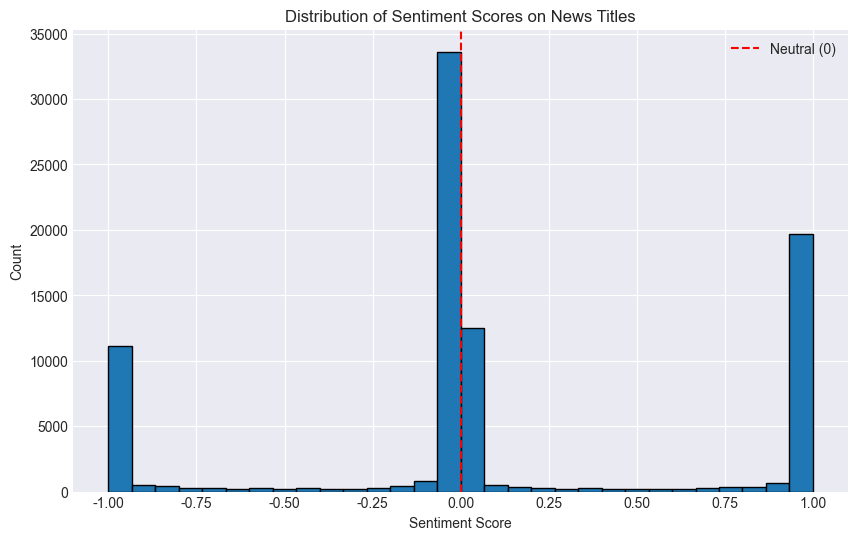


模型不确定性:
  平均不确定性: 0.423
  高不确定性样本(>0.5): 36072 条


In [34]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/finbert_output/time_2019-2020_FNSPID_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# # 查看最高和最低的几个样本
# print("\n最正面样本:")
# for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
#     print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# print("\n最负面样本:")
# for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
#     print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")



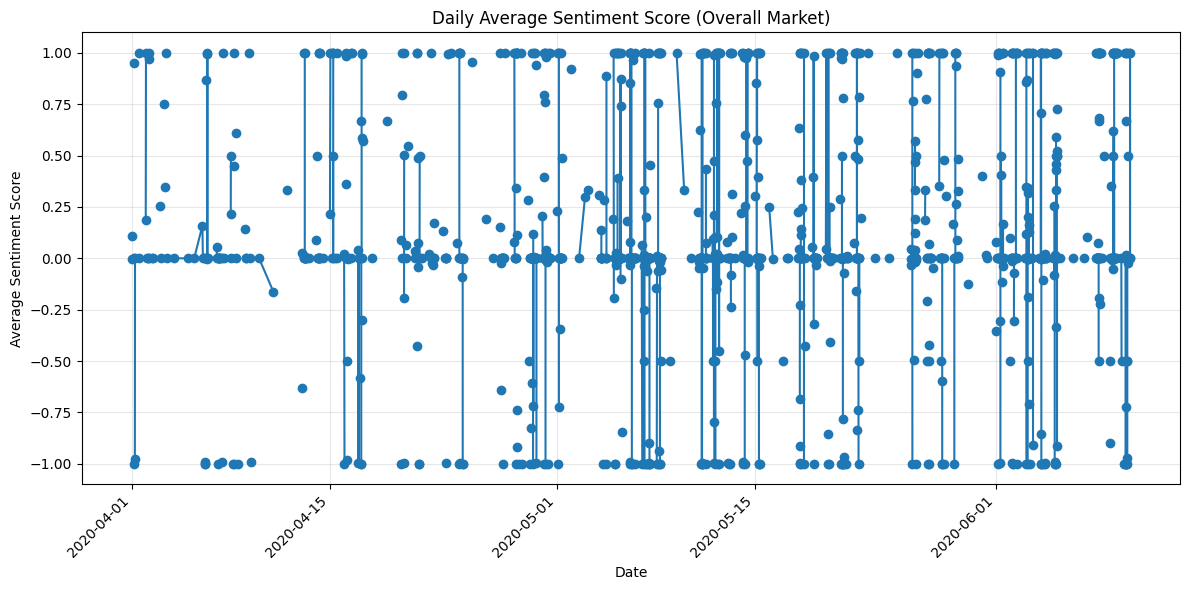

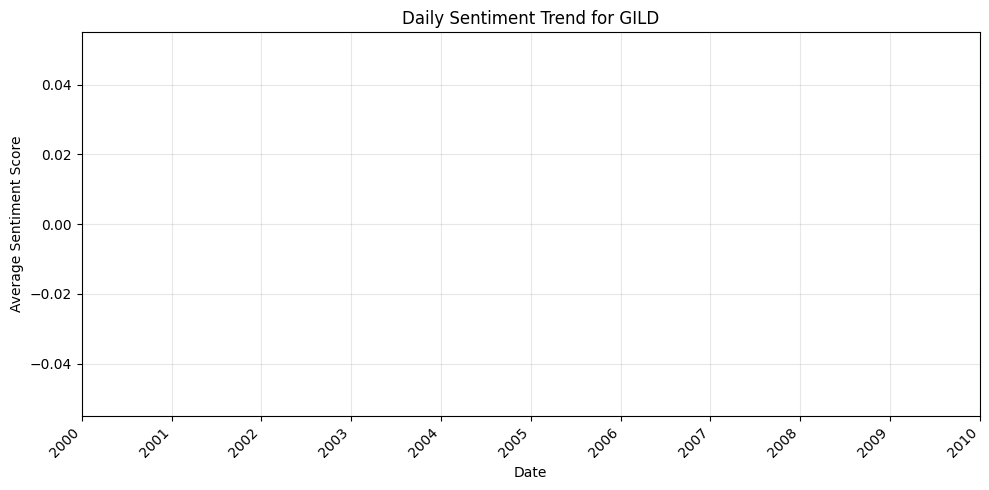

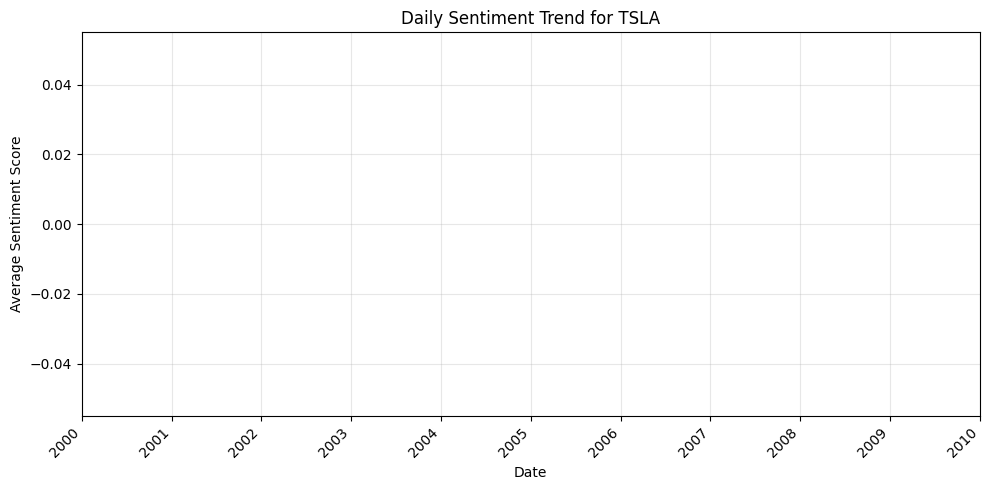

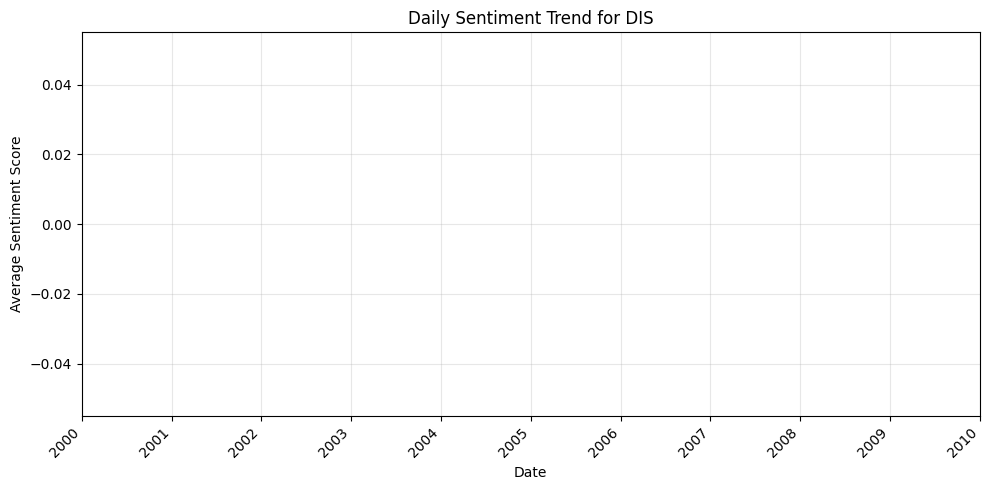

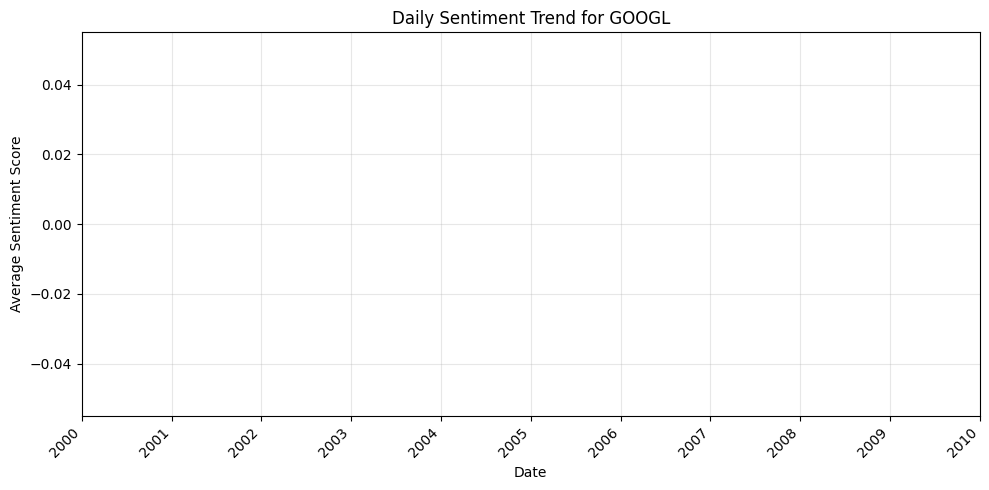

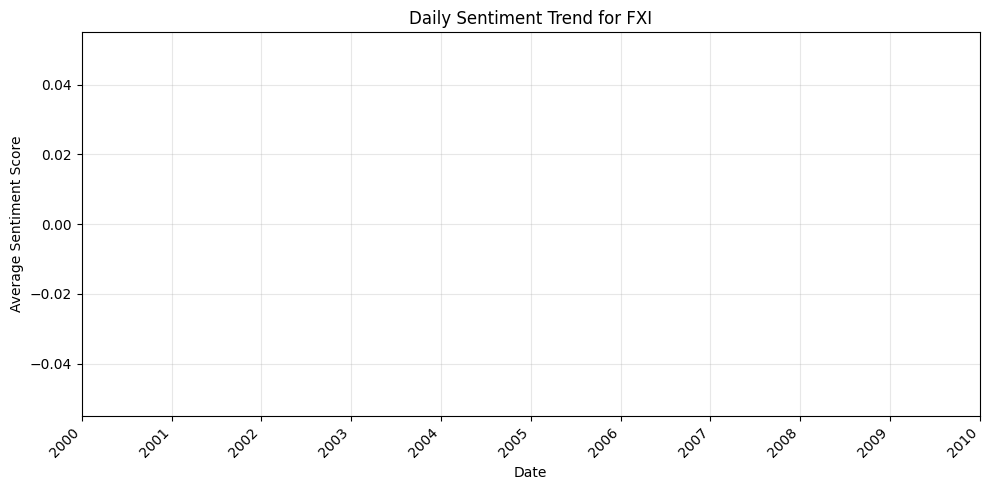

In [20]:
# 按日期分析（如果有pubDate）

# 绘制每日情感趋势（整体市场）
plt.figure(figsize=(12, 6))
daily_avg = result_df.groupby('Date')['sentiment_score'].mean()
daily_avg.plot(kind='line', marker='o')
plt.title('Daily Average Sentiment Score (Overall Market)')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绘制特定股票的情感趋势（如果有足够数据）
top_stocks = result_df['Stock_symbol'].value_counts().head(5).index
for stock in top_stocks:
    stock_data = result_df[result_df['Stock_symbol'] == stock]
    if len(stock_data) > 5:  # 至少5个数据点
        daily_stock = stock_data.groupby('Date')['sentiment_score'].mean()
        plt.figure(figsize=(10, 5))
        daily_stock.plot(kind='line', marker='o')
        plt.title(f'Daily Sentiment Trend for {stock}')
        plt.xlabel('Date')
        plt.ylabel('Average Sentiment Score')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### 股票情绪分析的必要数据统计

In [ ]:
print("\n" + "="*60)
print("Step 4.5: 数据清洗和股票情绪分析")
print("="*60)

# 过滤掉没有新闻的股票（news_count = 0 或 NaN）
filtered_stock_sentiment = daily_stock_sentiment[
    (daily_stock_sentiment['news_count'] > 0) & 
    (daily_stock_sentiment['Stock_symbol'].notna())
].copy()
print(f"过滤前股票-日期组合: {len(daily_stock_sentiment)}")
print(f"过滤后有新闻的股票-日期组合: {len(filtered_stock_sentiment)}")

# 1. 每日股票新闻数量统计
print("\n" + "="*60)
print("每日股票新闻数量统计")
print("="*60)

# 每日有多少只股票有新闻
daily_stock_count = filtered_stock_sentiment.groupby('Date').size().reset_index(name='stock_count')
print(f"每日有新闻的股票数量统计:")
print(f"  平均每日: {daily_stock_count['stock_count'].mean():.2f} 只")
print(f"  最多每日: {daily_stock_count['stock_count'].max()} 只")
print(f"  最少每日: {daily_stock_count['stock_count'].min()} 只")

# 显示每日股票数量Top 10
print(f"\n每日股票数量最多的10天:")
print(daily_stock_count.nlargest(10, 'stock_count'))

# 2. 股票出现频率统计（哪些股票新闻最多）
print("\n" + "="*60)
print("股票新闻频率统计")
print("="*60)

# 统计每只股票出现的天数（有新闻的天数）
stock_frequency = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'Date': 'count',  # 有新闻的天数
    'news_count': 'sum',  # 总新闻数
    'avg_sentiment_score': 'mean'  # 平均情感分数
}).rename(columns={'Date': 'days_with_news', 'news_count': 'total_news'})

# 按有新闻的天数排序
stock_frequency_sorted = stock_frequency.sort_values('days_with_news', ascending=False)
print(f"共有 {len(stock_frequency)} 只股票有新闻")
print(f"\n新闻覆盖天数最多的前20只股票:")
print(stock_frequency_sorted.head(20))

# 3. 一周内必有新闻的股票（新闻覆盖率高）
print("\n" + "="*60)
print("一周内必有新闻的股票分析")
print("="*60)

# 计算总天数范围
total_days = len(filtered_stock_sentiment['Date'].unique())
print(f"数据总天数: {total_days} 天")

# 计算每只股票的新闻覆盖率
stock_frequency['coverage_rate'] = stock_frequency['days_with_news'] / total_days * 100

# 找出每周至少有一天有新闻的股票（覆盖率 >= 1/7 ≈ 14.3%）
weekly_coverage = stock_frequency[stock_frequency['coverage_rate'] >= (100/7)]
print(f"\n每周至少有一天有新闻的股票数量: {len(weekly_coverage)} 只")
print(f"占总股票数的比例: {len(weekly_coverage)/len(stock_frequency)*100:.1f}%")

# 找出几乎每天都有新闻的股票（覆盖率 >= 50%）
high_coverage = stock_frequency[stock_frequency['coverage_rate'] >= 50].sort_values('coverage_rate', ascending=False)
print(f"\n高覆盖率股票 (>=50%天数): {len(high_coverage)} 只")
print(high_coverage.head(20))

# 4. 每周新闻模式分析
print("\n" + "="*60)
print("每周新闻模式分析")
print("="*60)

# 添加星期几信息
filtered_stock_sentiment['Weekday'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.day_name()
filtered_stock_sentiment['Weekday_Num'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.dayofweek

# 按星期统计新闻数量
weekday_stats = filtered_stock_sentiment.groupby('Weekday_Num').agg({
    'news_count': 'sum',
    'Stock_symbol': 'nunique'  # 不同股票数量
}).reset_index()

# 映射星期名称
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday_stats['Weekday'] = weekday_stats['Weekday_Num'].map(weekday_map)

print("\n各星期新闻发布情况:")
for _, row in weekday_stats.iterrows():
    print(f"  {row['Weekday']}: 新闻总数={row['news_count']:,}, 股票数量={row['Stock_symbol']}")

# 5. 股票情绪波动分析
print("\n" + "="*60)
print("股票情绪波动分析")
print("="*60)

# 计算每只股票的情绪波动性
stock_volatility = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'avg_sentiment_score': ['mean', 'std', 'count']
}).reset_index()

stock_volatility.columns = ['Stock_symbol', 'avg_sentiment_mean', 'sentiment_volatility', 'days_count']
stock_volatility = stock_volatility[stock_volatility['days_count'] >= 5]  # 至少5天数据

# 找出情绪最极端的股票
print("\n情绪最正面（平均分数最高）的10只股票:")
positive_stocks = stock_volatility.nlargest(10, 'avg_sentiment_mean')
for _, row in positive_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪最负面（平均分数最低）的10只股票:")
negative_stocks = stock_volatility.nsmallest(10, 'avg_sentiment_mean')
for _, row in negative_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪波动最大的10只股票:")
volatile_stocks = stock_volatility.nlargest(10, 'sentiment_volatility')
for _, row in volatile_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 波动={row['sentiment_volatility']:.4f}, 平均={row['avg_sentiment_mean']:.4f}, 天数={row['days_count']}")

# 6. 时间序列分析 - 每日整体市场情绪
print("\n" + "="*60)
print("每日整体市场情绪趋势")
print("="*60)

# 计算每日整体平均情绪
daily_market_sentiment = filtered_stock_sentiment.groupby('Date')['avg_sentiment_score'].mean().reset_index()
print(f"市场情绪统计:")
print(f"  整体平均: {daily_market_sentiment['avg_sentiment_score'].mean():.4f}")
print(f"  最高日情绪: {daily_market_sentiment['avg_sentiment_score'].max():.4f}")
print(f"  最低日情绪: {daily_market_sentiment['avg_sentiment_score'].min():.4f}")

# 找出情绪最极端的日期
print(f"\n市场情绪最正面的5天:")
positive_days = daily_market_sentiment.nlargest(5, 'avg_sentiment_score')
for _, row in positive_days.iterrows():
    print(f"  {row['Date'].date()}: {row['avg_sentiment_score']:.4f}")

print(f"\n市场情绪最负面的5天:")
negative_days = daily_market_sentiment.nsmallest(5, 'avg_sentiment_score')
for _, row in negative_days.iterrows():
    print(f"  {row['Date'].date()}: {row['avg_sentiment_score']:.4f}")

# 7. 保存分析结果
print("\n" + "="*60)
print("保存分析结果")
print("="*60)

os.makedirs("02_A_finbert/finbert_output/time_2019-2020", exist_ok=True)


# 保存清洗后的每日每只股数据
cleaned_output = "02_A_finbert/finbert_output/time_2019-2020/FNSPID_daily_stock_sentiment_cleaned.csv"
filtered_stock_sentiment.to_csv(cleaned_output, index=False)
print(f"✅ 清洗后的每日每只股数据已保存: {cleaned_output}")

# 保存股票频率统计
frequency_output = "02_A_finbert/finbert_output/time_2019-2020/FNSPID_stock_frequency.csv"
stock_frequency_sorted.to_csv(frequency_output)
print(f"✅ 股票频率统计已保存: {frequency_output}")

# 保存股票情绪波动统计
volatility_output = "02_A_finbert/finbert_output/time_2019-2020/FNSPID_stock_volatility.csv"
stock_volatility.to_csv(volatility_output, index=False)
print(f"✅ 股票情绪波动统计已保存: {volatility_output}")

# 保存每日市场情绪
market_sentiment_output = "02_A_finbert/finbert_output/time_2019-2020/FNSPID_market_sentiment_daily.csv"
daily_market_sentiment.to_csv(market_sentiment_output, index=False)
print(f"✅ 每日市场情绪已保存: {market_sentiment_output}")

print(f"\n📊 分析完成! 共分析了 {len(filtered_stock_sentiment)} 条股票-日期记录")
print(f"📈 涉及 {len(stock_frequency)} 只股票, 覆盖 {total_days} 天")


Step 4.5: 数据清洗和股票情绪分析
过滤前股票-日期组合: 55321
过滤后有新闻的股票-日期组合: 2325

每日股票新闻数量统计
每日有新闻的股票数量统计:
  平均每日: 1.94 只
  最多每日: 44 只
  最少每日: 1 只

每日股票数量最多的10天:
          Date  stock_count
0   2020-04-01           44
99  2020-04-15           44
27  2020-04-06           42
72  2020-04-13           40
40  2020-04-07           39
63  2020-04-09           39
86  2020-04-14           37
53  2020-04-08           34
127 2020-04-17           34
157 2020-04-21           31

股票新闻频率统计
共有 181 只股票有新闻

新闻覆盖天数最多的前20只股票:
              days_with_news  total_news  avg_sentiment_score
Stock_symbol                                                 
AAPL                      66         311             0.103896
AMZN                      45         278             0.172351
ALK                       41          81             0.221829
AMD                       40          80             0.210247
AAL                       39          69             0.095070
AIG                       35          49            -0.083680
AMTD       


#### 关键功能说明：

##### 1. **数据清洗**
- 过滤掉 `news_count = 0` 的记录（没有新闻的日期-股票组合）
- 过滤掉 `Stock_symbol` 为空的记录

##### 2. **股票频率分析**
- 每只股票出现的天数
- 每只股票的总新闻数
- 新闻覆盖率（出现天数/总天数）

##### 3. **一周内必有新闻的股票**
- 计算每周至少有一天有新闻的股票（覆盖率 >= 14.3%）
- 高覆盖率股票（>=50%天数）

##### 4. **每周新闻模式**
- 按星期统计新闻发布情况
- 了解哪些工作日新闻更多

##### 5. **情绪波动分析**
- 情绪最正面/最负面的股票
- 情绪波动最大的股票

##### 6. **市场情绪趋势**
- 每日整体市场情绪
- 极端情绪日识别

##### 7. **输出文件**
- `FNSPID_daily_stock_sentiment_cleaned.csv`: 清洗后的每日每只股数据
- `FNSPID_stock_frequency.csv`: 股票频率统计
- `FNSPID_stock_volatility.csv`: 股票情绪波动统计  
- `FNSPID_market_sentiment_daily.csv`: 每日市场情绪

这些分析结果可以帮助您：
- 识别重要股票（新闻覆盖率高）
- 了解新闻发布的时间模式
- 分析不同股票的情绪特征
- 为后续的股票收益预测提供特征

### 可视化图表


Step 5: 股票情绪分析可视化


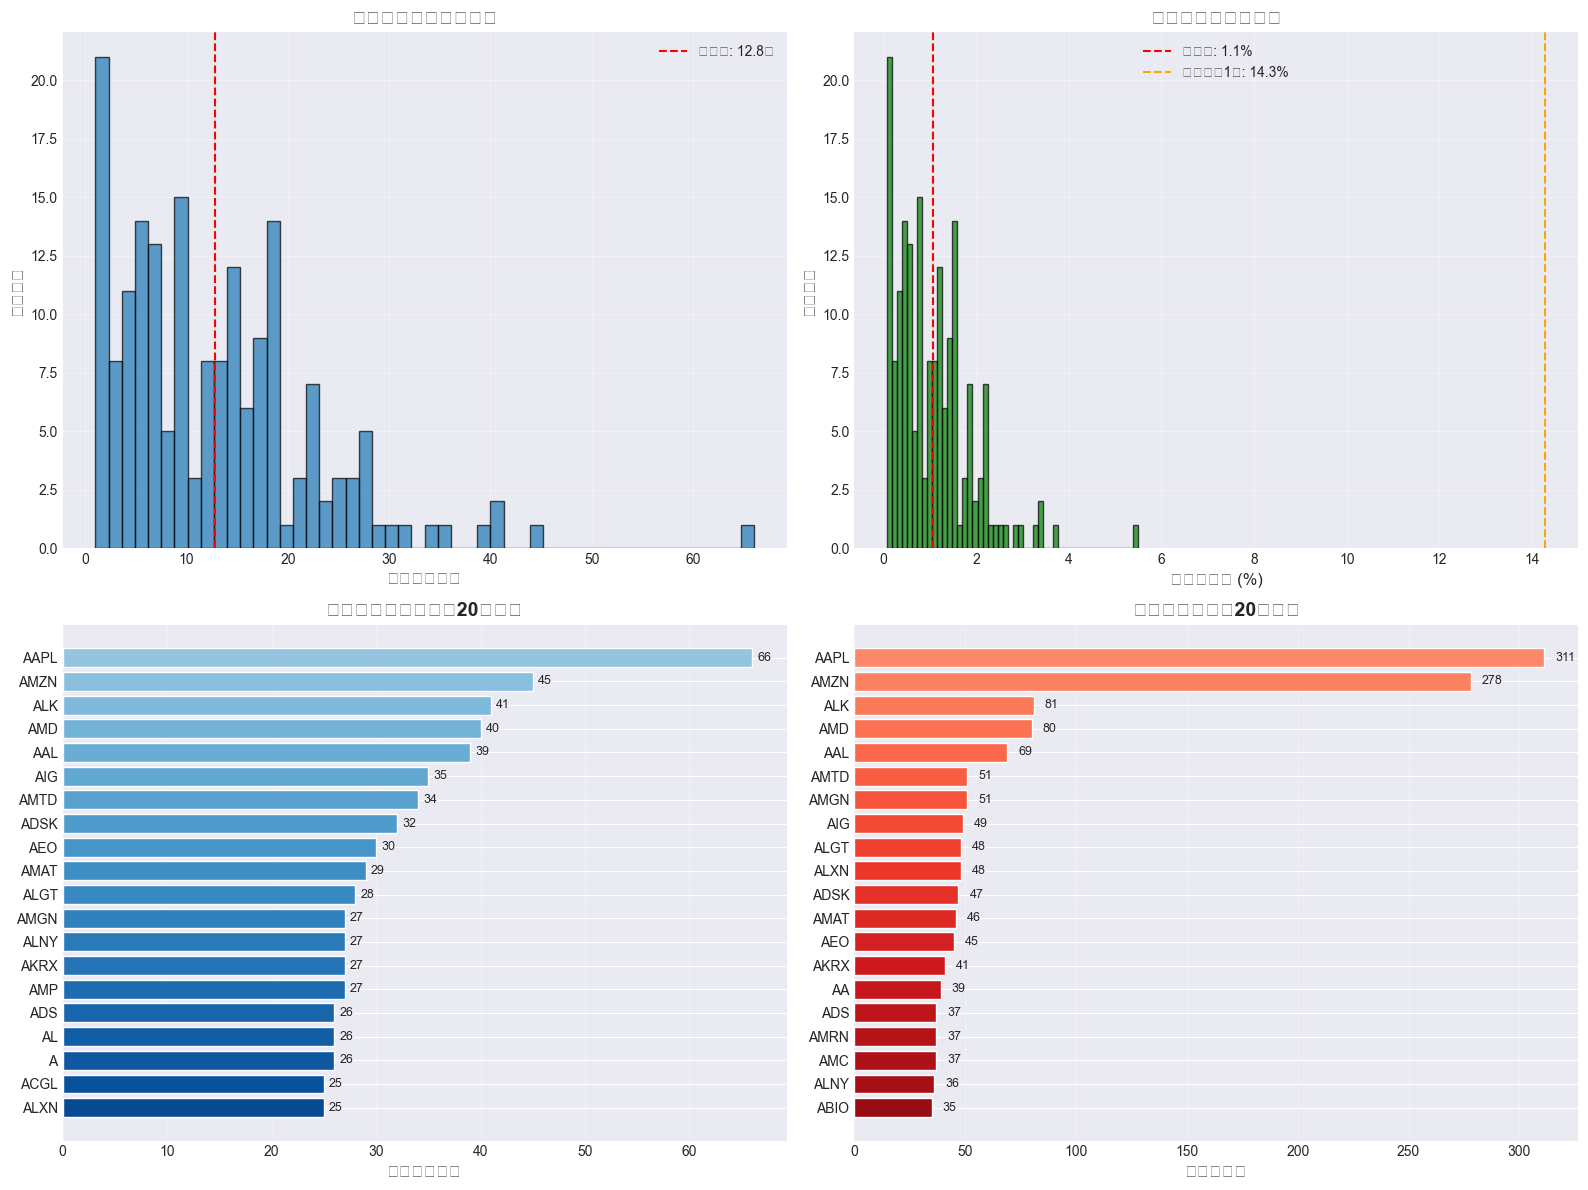

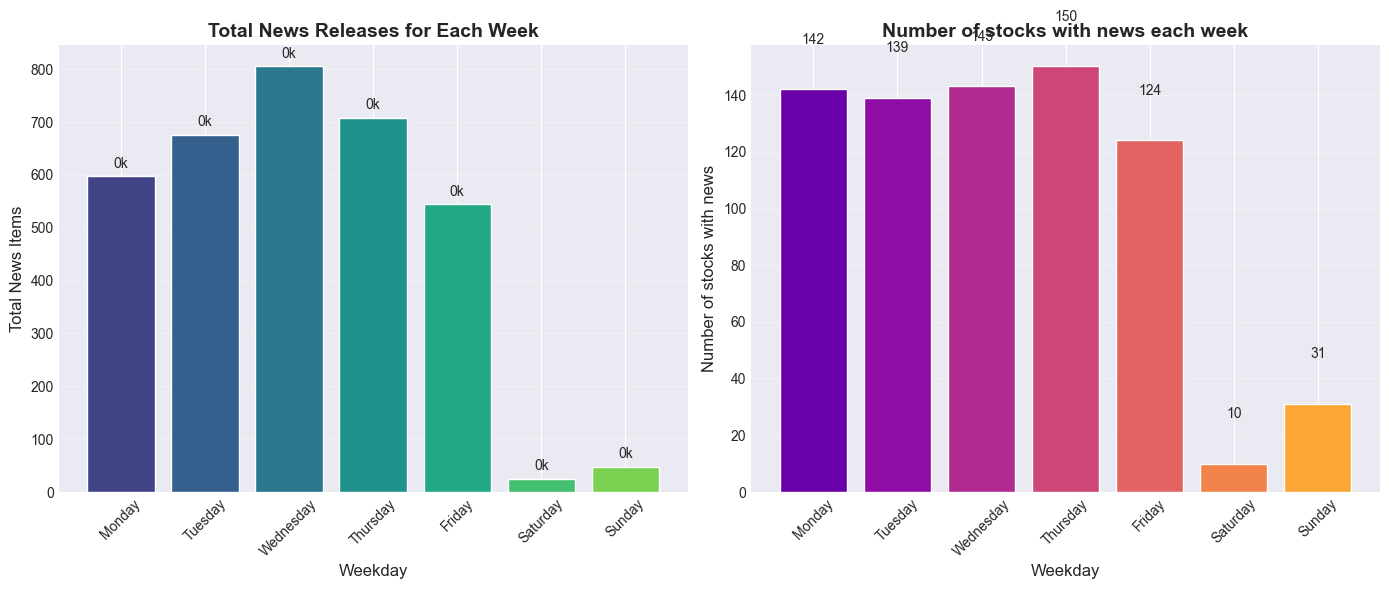

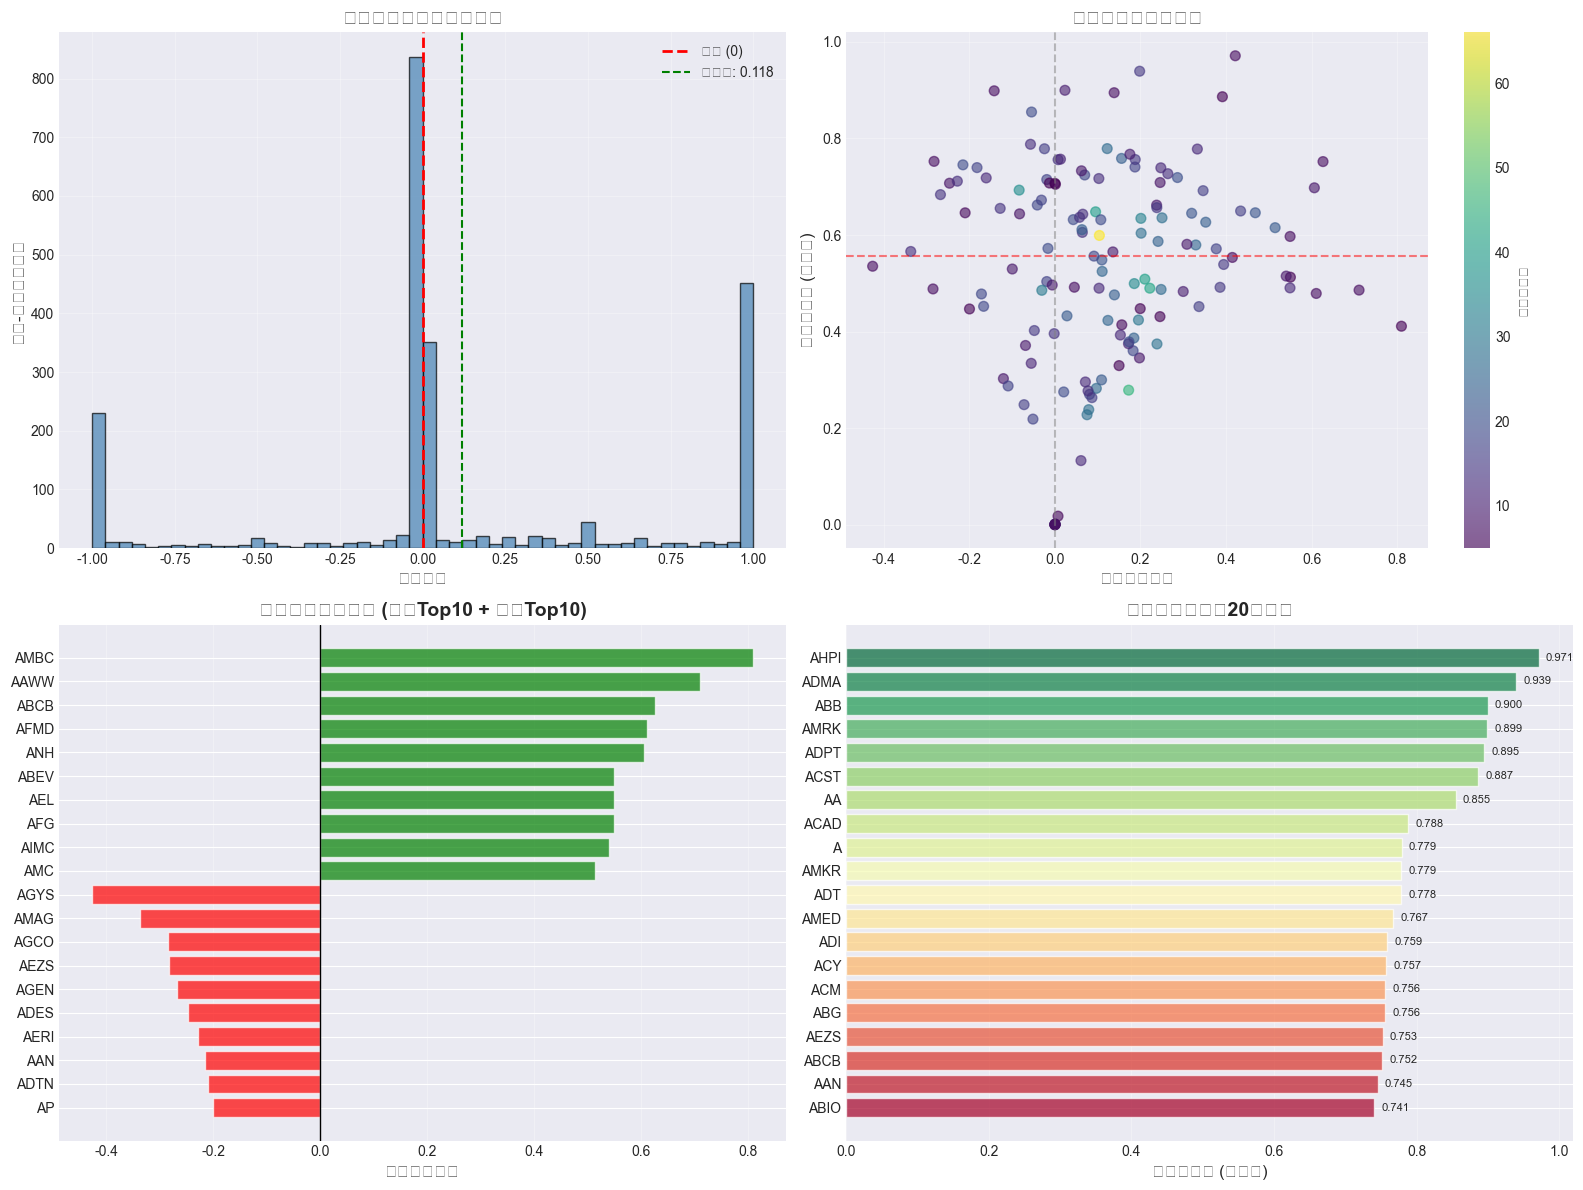

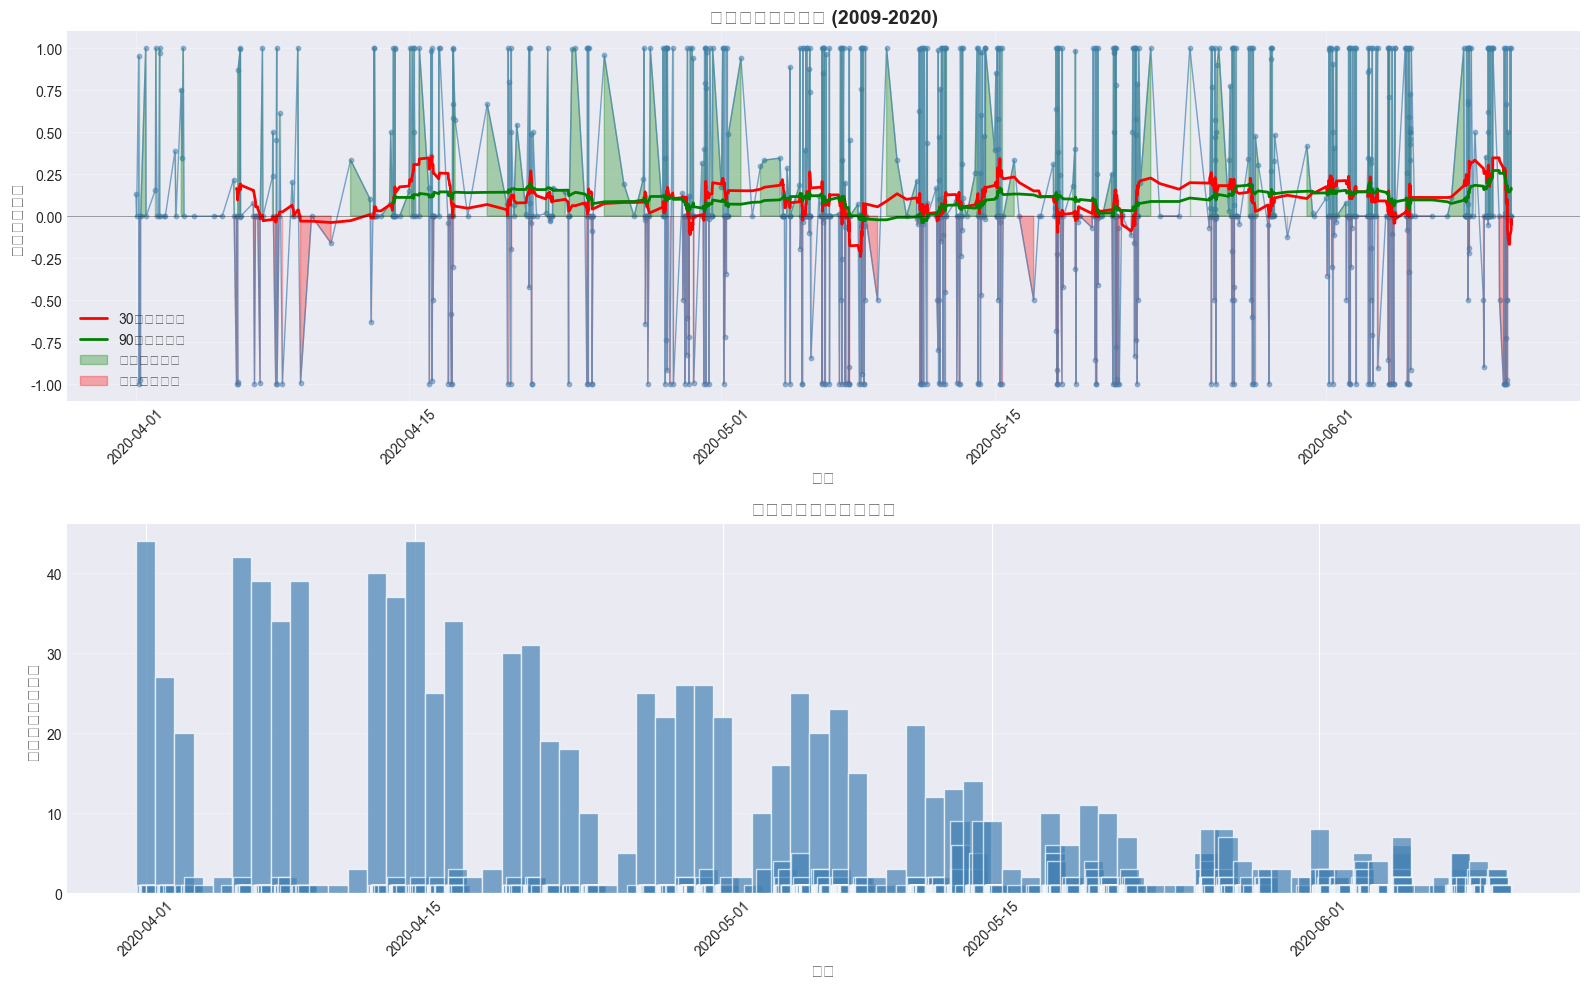

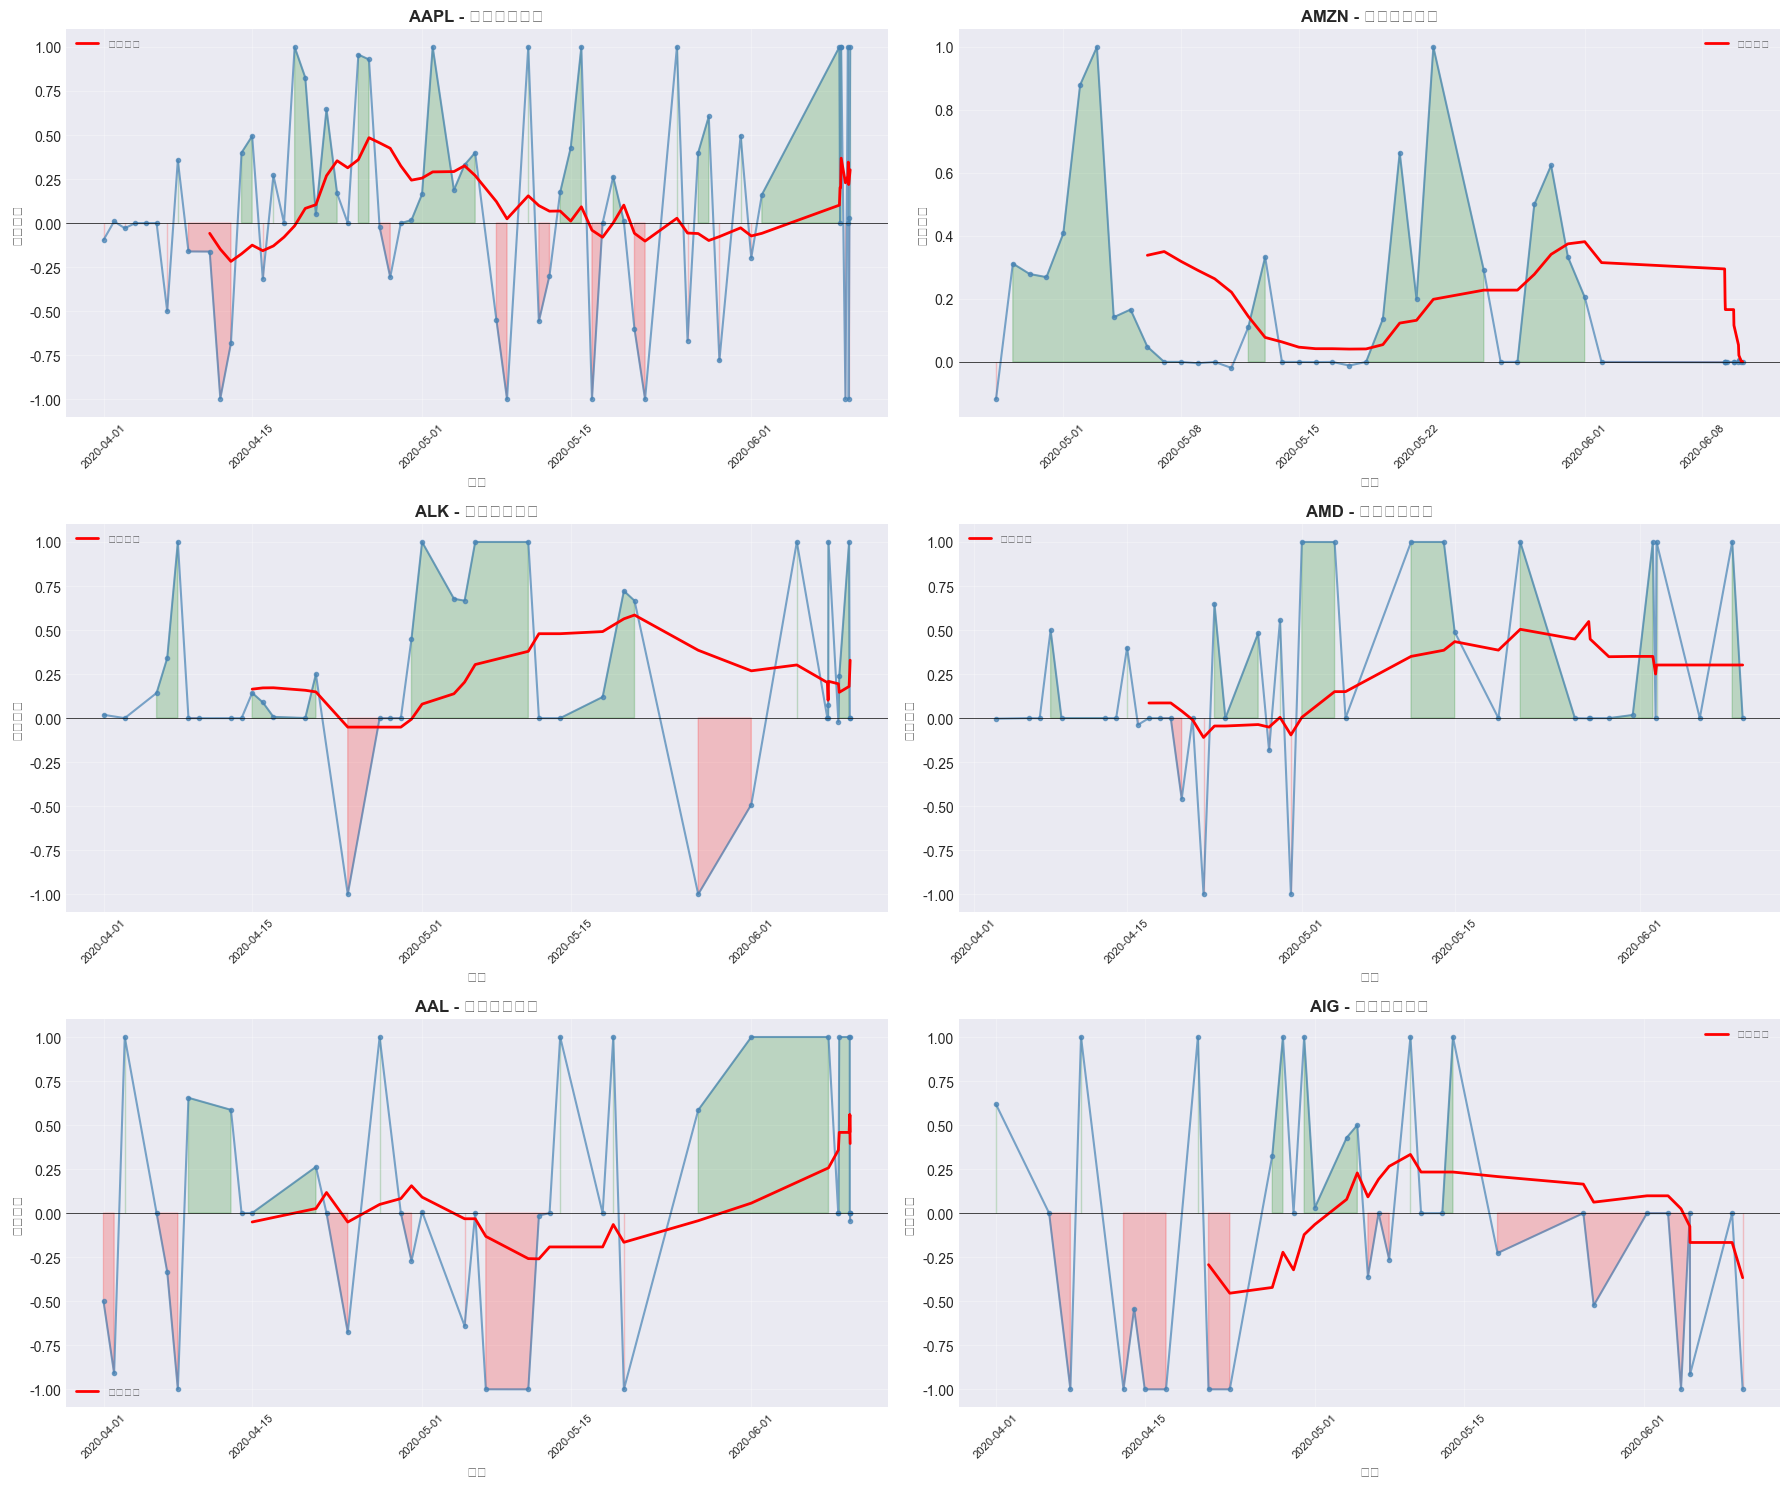

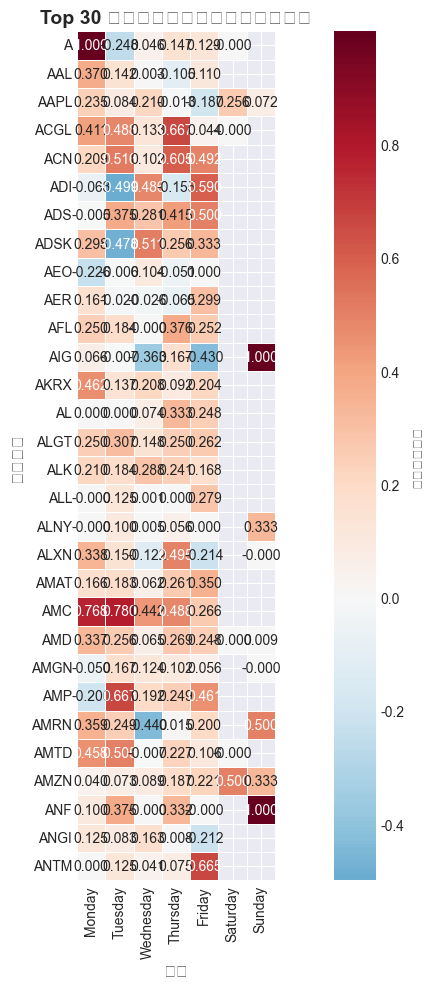


统计摘要

📊 数据概览:
  - 分析时间段: 2020-04-01 到 2020-06-10
  - 总天数: 1200 天
  - 总股票数量: 181 只
  - 总股票-日期组合: 2325 条

📈 新闻覆盖统计:
  - 平均每天有新闻的股票: 1.94 只
  - 中位数每天有新闻的股票: 1 只
  - 股票平均覆盖天数: 12.85 天
  - 股票平均覆盖率: 1.07%

🎭 情绪统计:
  - 整体平均情感分数: 0.1176
  - 情绪标准差: 0.5762
  - 最正面情绪: 1.0000
  - 最负面情绪: -1.0000

📅 星期模式:
  - Monday: 597 条新闻, 142 只股票
  - Tuesday: 676 条新闻, 139 只股票
  - Wednesday: 805 条新闻, 143 只股票
  - Thursday: 708 条新闻, 150 只股票
  - Friday: 545 条新闻, 124 只股票
  - Saturday: 25 条新闻, 10 只股票
  - Sunday: 48 条新闻, 31 只股票

🏆 Top 5 高频股票:

✅ 所有图表已保存到: 02_A_finbert/finbert_output/time_2019-2020/figures/


In [ ]:
print("\n" + "="*60)
print("Step 5: 股票情绪分析可视化")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')

# 创建图表目录
os.makedirs("02_A_finbert/finbert_output/time_2019-2020/figures", exist_ok=True)

# ============================================
# 1. 股票新闻覆盖频率分布
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 股票出现天数分布
ax1 = axes[0, 0]
stock_frequency['days_with_news'].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_xlabel('有新闻的天数', fontsize=12)
ax1.set_ylabel('股票数量', fontsize=12)
ax1.set_title('股票新闻覆盖天数分布', fontsize=14, fontweight='bold')
ax1.axvline(stock_frequency['days_with_news'].mean(), color='red', linestyle='--', 
            label=f'平均值: {stock_frequency["days_with_news"].mean():.1f}天')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.2 股票覆盖率分布
ax2 = axes[0, 1]
stock_frequency['coverage_rate'].hist(bins=50, edgecolor='black', alpha=0.7, color='green', ax=ax2)
ax2.set_xlabel('新闻覆盖率 (%)', fontsize=12)
ax2.set_ylabel('股票数量', fontsize=12)
ax2.set_title('股票新闻覆盖率分布', fontsize=14, fontweight='bold')
ax2.axvline(stock_frequency['coverage_rate'].mean(), color='red', linestyle='--', 
            label=f'平均值: {stock_frequency["coverage_rate"].mean():.1f}%')
ax2.axvline(100/7, color='orange', linestyle='--', 
            label=f'每周至少1天: {100/7:.1f}%')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 1.3 Top 20 股票新闻覆盖天数
ax3 = axes[1, 0]
top20_stocks = stock_frequency_sorted.head(20)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20_stocks)))
bars = ax3.barh(range(len(top20_stocks)), top20_stocks['days_with_news'].values, color=colors)
ax3.set_yticks(range(len(top20_stocks)))
ax3.set_yticklabels(top20_stocks.index, fontsize=10)
ax3.set_xlabel('有新闻的天数', fontsize=12)
ax3.set_title('新闻覆盖天数最多的20只股票', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, top20_stocks['days_with_news'].values)):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', va='center', fontsize=9)

# 1.4 总新闻数 Top 20
ax4 = axes[1, 1]
top20_news = stock_frequency_sorted.nlargest(20, 'total_news')
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top20_news)))
bars = ax4.barh(range(len(top20_news)), top20_news['total_news'].values, color=colors)
ax4.set_yticks(range(len(top20_news)))
ax4.set_yticklabels(top20_news.index, fontsize=10)
ax4.set_xlabel('总新闻数量', fontsize=12)
ax4.set_title('新闻总数最多的20只股票', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, top20_news['total_news'].values)):
    ax4.text(val + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/01_stock_coverage_distribution.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 2. 每周新闻模式分析
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2.1 按星期统计新闻总数
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats['Weekday'] = pd.Categorical(weekday_stats['Weekday'], categories=weekday_order, ordered=True)
weekday_stats_sorted = weekday_stats.sort_values('Weekday')

ax1 = axes[0]
bars = ax1.bar(weekday_stats_sorted['Weekday'], weekday_stats_sorted['news_count'], 
               color=plt.cm.viridis(np.linspace(0.2, 0.8, 7)))
ax1.set_xlabel('Weekday', fontsize=12)
ax1.set_ylabel('Total News Items', fontsize=12)
ax1.set_title('Total News Releases for Each Week', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# # 添加数值标签
# for bar, val in zip(bars, weekday_stats_sorted['news_count']):
#     ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
#              f'{int(val/1000)}k', ha='center', fontsize=10)
    
# 添加数值标签
for bar, val in zip(bars, weekday_stats_sorted['news_count']):
    max_height = weekday_stats_sorted['news_count'].max()
    offset = max_height * 0.02  # 偏移量为最大值的2%
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
            f'{int(val/1000)}k', ha='center', fontsize=10)

# 2.2 按星期统计股票数量
ax2 = axes[1]
bars = ax2.bar(weekday_stats_sorted['Weekday'], weekday_stats_sorted['Stock_symbol'], 
               color=plt.cm.plasma(np.linspace(0.2, 0.8, 7)))
ax2.set_xlabel('Weekday', fontsize=12)
ax2.set_ylabel('Number of stocks with news', fontsize=12)
ax2.set_title('Number of stocks with news each week', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, weekday_stats_sorted['Stock_symbol']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'{int(val)}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/02_weekly_pattern.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 3. 股票情绪分析
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 情绪分数分布
ax1 = axes[0, 0]
filtered_stock_sentiment['avg_sentiment_score'].hist(bins=50, edgecolor='black', 
                                                      alpha=0.7, color='steelblue', ax=ax1)
ax1.set_xlabel('情感分数', fontsize=12)
ax1.set_ylabel('股票-日期组合数量', fontsize=12)
ax1.set_title('每日每只股情感分数分布', fontsize=14, fontweight='bold')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='中性 (0)')
ax1.axvline(filtered_stock_sentiment['avg_sentiment_score'].mean(), 
            color='green', linestyle='--', 
            label=f'平均值: {filtered_stock_sentiment["avg_sentiment_score"].mean():.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3.2 情绪波动 vs 平均情绪
ax2 = axes[0, 1]
scatter = ax2.scatter(stock_volatility['avg_sentiment_mean'], 
                     stock_volatility['sentiment_volatility'],
                     c=stock_volatility['days_count'], 
                     cmap='viridis', alpha=0.6, s=50)
ax2.set_xlabel('平均情感分数', fontsize=12)
ax2.set_ylabel('情感波动性 (标准差)', fontsize=12)
ax2.set_title('股票情绪波动性分析', fontsize=14, fontweight='bold')
ax2.axhline(y=stock_volatility['sentiment_volatility'].median(), 
            color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('有新闻天数', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3.3 情绪最极端的股票 (Top 10 正面 + 负面)
ax3 = axes[1, 0]
top_positive = stock_volatility.nlargest(10, 'avg_sentiment_mean')
top_negative = stock_volatility.nsmallest(10, 'avg_sentiment_mean')
extreme_stocks = pd.concat([top_positive, top_negative])
colors = ['green'] * 10 + ['red'] * 10
bars = ax3.barh(range(len(extreme_stocks)), extreme_stocks['avg_sentiment_mean'].values, 
                color=colors, alpha=0.7)
ax3.set_yticks(range(len(extreme_stocks)))
ax3.set_yticklabels(extreme_stocks['Stock_symbol'], fontsize=10)
ax3.set_xlabel('平均情感分数', fontsize=12)
ax3.set_title('情绪最极端的股票 (正面Top10 + 负面Top10)', fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 3.4 情绪波动最大的股票
ax4 = axes[1, 1]
top_volatile = stock_volatility.nlargest(20, 'sentiment_volatility')
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_volatile)))
bars = ax4.barh(range(len(top_volatile)), top_volatile['sentiment_volatility'].values, 
                color=colors, alpha=0.7)
ax4.set_yticks(range(len(top_volatile)))
ax4.set_yticklabels(top_volatile['Stock_symbol'], fontsize=10)
ax4.set_xlabel('情感波动性 (标准差)', fontsize=12)
ax4.set_title('情感波动最大的20只股票', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_volatile['sentiment_volatility'].values)):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/03_stock_sentiment_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 4. 市场情绪时间序列
# ============================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 4.1 每日市场情绪趋势
ax1 = axes[0]
daily_market_sentiment['Date'] = pd.to_datetime(daily_market_sentiment['Date'])
ax1.plot(daily_market_sentiment['Date'], daily_market_sentiment['avg_sentiment_score'], 
         linewidth=1, color='steelblue', alpha=0.7)
ax1.scatter(daily_market_sentiment['Date'], daily_market_sentiment['avg_sentiment_score'], 
            s=10, alpha=0.5, color='steelblue')

# 添加移动平均线
ma_30 = daily_market_sentiment['avg_sentiment_score'].rolling(window=30).mean()
ma_90 = daily_market_sentiment['avg_sentiment_score'].rolling(window=90).mean()
ax1.plot(daily_market_sentiment['Date'], ma_30, linewidth=2, color='red', label='30日移动平均')
ax1.plot(daily_market_sentiment['Date'], ma_90, linewidth=2, color='green', label='90日移动平均')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.fill_between(daily_market_sentiment['Date'], 0, daily_market_sentiment['avg_sentiment_score'],
                  where=(daily_market_sentiment['avg_sentiment_score'] > 0), 
                  color='green', alpha=0.3, label='正面情绪区域')
ax1.fill_between(daily_market_sentiment['Date'], 0, daily_market_sentiment['avg_sentiment_score'],
                  where=(daily_market_sentiment['avg_sentiment_score'] < 0), 
                  color='red', alpha=0.3, label='负面情绪区域')

ax1.set_xlabel('日期', fontsize=12)
ax1.set_ylabel('平均情感分数', fontsize=12)
ax1.set_title('每日市场情绪趋势 (2009-2020)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# 4.2 每日有新闻的股票数量
ax2 = axes[1]
daily_stock_count = filtered_stock_sentiment.groupby('Date').size().reset_index(name='stock_count')
ax2.bar(daily_stock_count['Date'], daily_stock_count['stock_count'], 
        color='steelblue', alpha=0.7, width=1)
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('有新闻的股票数量', fontsize=12)
ax2.set_title('每日有新闻的股票数量', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/04_market_sentiment_trend.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. Top 股票情绪时间序列
# ============================================
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# 选择前6只最常出现新闻的股票
top6_stocks = stock_frequency_sorted.head(6).index.tolist()
axes_flat = axes.flatten()

for idx, stock in enumerate(top6_stocks):
    ax = axes_flat[idx]
    stock_data = filtered_stock_sentiment[filtered_stock_sentiment['Stock_symbol'] == stock].copy()
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    stock_data = stock_data.sort_values('Date')
    
    ax.plot(stock_data['Date'], stock_data['avg_sentiment_score'], 
            linewidth=1.5, marker='o', markersize=3, color='steelblue', alpha=0.7)
    
    # 添加移动平均
    if len(stock_data) > 10:
        ma = stock_data['avg_sentiment_score'].rolling(window=min(10, len(stock_data)//3)).mean()
        ax.plot(stock_data['Date'], ma, linewidth=2, color='red', label='移动平均')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                    where=(stock_data['avg_sentiment_score'] > 0), 
                    color='green', alpha=0.2)
    ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                    where=(stock_data['avg_sentiment_score'] < 0), 
                    color='red', alpha=0.2)
    
    ax.set_title(f'{stock} - 情感分数趋势', fontsize=12, fontweight='bold')
    ax.set_xlabel('日期', fontsize=10)
    ax.set_ylabel('情感分数', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/05_top_stocks_sentiment_trend.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. 情绪分布热力图 (股票 vs 星期)
# ============================================
fig, ax = plt.subplots(figsize=(12, 10))

# 创建股票-星期平均情感矩阵
filtered_stock_sentiment['Weekday'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 选择新闻最多的30只股票
top30_stocks = stock_frequency_sorted.head(30).index.tolist()
stock_weekday_sentiment = filtered_stock_sentiment[
    filtered_stock_sentiment['Stock_symbol'].isin(top30_stocks)
].groupby(['Stock_symbol', 'Weekday'])['avg_sentiment_score'].mean().unstack()

# 重新排序星期和股票
stock_weekday_sentiment = stock_weekday_sentiment.reindex(columns=weekday_order)
stock_weekday_sentiment = stock_weekday_sentiment.dropna(axis=0, how='all')

# 绘制热力图
sns.heatmap(stock_weekday_sentiment, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'label': '平均情感分数'})
ax.set_title('Top 30 股票在不同星期的平均情感分数', fontsize=14, fontweight='bold')
ax.set_xlabel('星期', fontsize=12)
ax.set_ylabel('股票代码', fontsize=12)

plt.tight_layout()
plt.savefig('02_A_finbert/finbert_output/time_2019-2020/figures/06_stock_weekday_sentiment_heatmap.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 7. 统计摘要表格
# ============================================
print("\n" + "="*60)
print("统计摘要")
print("="*60)

print(f"\n📊 数据概览:")
print(f"  - 分析时间段: {filtered_stock_sentiment['Date'].min().date()} 到 {filtered_stock_sentiment['Date'].max().date()}")
print(f"  - 总天数: {total_days} 天")
print(f"  - 总股票数量: {len(stock_frequency)} 只")
print(f"  - 总股票-日期组合: {len(filtered_stock_sentiment)} 条")

print(f"\n📈 新闻覆盖统计:")
print(f"  - 平均每天有新闻的股票: {daily_stock_count['stock_count'].mean():.2f} 只")
print(f"  - 中位数每天有新闻的股票: {daily_stock_count['stock_count'].median():.0f} 只")
print(f"  - 股票平均覆盖天数: {stock_frequency['days_with_news'].mean():.2f} 天")
print(f"  - 股票平均覆盖率: {stock_frequency['coverage_rate'].mean():.2f}%")

print(f"\n🎭 情绪统计:")
print(f"  - 整体平均情感分数: {filtered_stock_sentiment['avg_sentiment_score'].mean():.4f}")
print(f"  - 情绪标准差: {filtered_stock_sentiment['avg_sentiment_score'].std():.4f}")
print(f"  - 最正面情绪: {filtered_stock_sentiment['avg_sentiment_score'].max():.4f}")
print(f"  - 最负面情绪: {filtered_stock_sentiment['avg_sentiment_score'].min():.4f}")

print(f"\n📅 星期模式:")
for _, row in weekday_stats_sorted.iterrows():
    print(f"  - {row['Weekday']}: {row['news_count']:,} 条新闻, {row['Stock_symbol']} 只股票")

print(f"\n🏆 Top 5 高频股票:")
# for stock in top5_stocks:
#     data = stock_frequency.loc[stock]
#     print(f"  - {stock}: {data['days_with_news']} 天 ({data['coverage_rate']:.1f}%), {data['total_news']} 条新闻")

print(f"\n✅ 所有图表已保存到: 02_A_finbert/finbert_output/time_2019-2020/figures/")

In [27]:
import matplotlib
print(matplotlib.__version__)  # 应该显示 3.5+ 或更高版本
from matplotlib import cm
print(cm.viridis)  # 不再报错

3.10.7




#### 生成的可视化图表说明：

##### 1. **股票新闻覆盖分布图** (`01_stock_coverage_distribution.png`)
- 股票覆盖天数分布直方图
- 股票覆盖率分布直方图
- Top 20 股票覆盖天数排名
- Top 20 股票新闻总数排名

##### 2. **每周新闻模式图** (`02_weekly_pattern.png`)
- 各星期新闻发布总量
- 各星期有新闻的股票数量

##### 3. **股票情绪分析图** (`03_stock_sentiment_analysis.png`)
- 情感分数分布直方图
- 情绪波动性散点图（波动 vs 平均值）
- 情绪最极端股票排名
- 情绪波动最大股票排名

##### 4. **市场情绪趋势图** (`04_market_sentiment_trend.png`)
- 每日市场情绪时间序列（含移动平均线）
- 每日有新闻的股票数量柱状图

##### 5. **Top股票情绪趋势图** (`05_top_stocks_sentiment_trend.png`)
- 前6只高频股票的情感分数时间序列
- 每只股票独立的情绪趋势图

##### 6. **股票-星期热力图** (`06_stock_weekday_sentiment_heatmap.png`)
- Top 30 股票在不同星期的平均情感分数
- 热力图展示股票情绪的时间模式

这些可视化图表全面展示了：
- 新闻覆盖的时间分布
- 股票新闻频率特征
- 情绪分布和波动特征
- 市场情绪趋势
- 个股情绪变化
- 星期模式分析

所有图表都会自动保存到 `02_A_finbert/finbert_output/figures/` 目录下。

### 验证fn 完整

In [ ]:

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")




print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")





print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)





print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")




import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/finbert_output/FNSPID_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")




import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")



print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")


print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")



import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/finbert_output/FNSPID_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")
